# 06 · Threshold and Review Capacity

Translate model scores into operational choices and quantify the trade-off between fraud recovered and investigations created.

## Reading guide

This notebook is part of a connected workflow. It states the decision being made, shows the supporting checks and records limitations alongside the result. Source files are never modified in place.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("FIFAR_DATA_DIR", PROJECT_ROOT / "data" / "raw" / "FiFAR"))
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Set FIFAR_DATA_DIR to the extracted official FiFAR directory before running this notebook."
    )

In [2]:
metrics = json.loads((REPORTS / 'model_metrics.json').read_text())
selected = metrics['models']['hist_gradient_boosting']

## 1. Two different decisions

A score threshold fixes a risk boundary. A capacity rule reviews the highest-risk cases until the available queue is full. In a changing population, the two policies do not necessarily produce the same volume.

In [3]:
pd.Series({'validation_f2_threshold': selected['validation_threshold_f2'], **selected['test']})

validation_f2_threshold    0.787840
average_precision          0.178916
roc_auc                    0.873893
precision                  0.174357
recall                     0.394258
balanced_accuracy          0.683158
alert_rate                 0.033343
dtype: float64

## 2. Fixed-capacity scenarios

In [4]:
capacity = pd.DataFrame(selected['test_capacity'])
capacity

,review_share,review_capacity,fraud_captured,precision_at_capacity,recall_at_capacity
0,0.01,968,285,0.294421,0.199580
1,0.03,2905,533,0.183477,0.373249
2,0.05,4842,680,0.140438,0.476190
3,0.10,9684,891,0.092007,0.623950


In [5]:
capacity["fraud_missed"] = 1428 - capacity["fraud_captured"]
capacity["false_positive_reviews"] = capacity["review_capacity"] - capacity["fraud_captured"]
capacity[["review_share", "review_capacity", "fraud_captured", "fraud_missed", "false_positive_reviews"]]

,review_share,review_capacity,fraud_captured,fraud_missed,false_positive_reviews
0,0.01,968,285,1143,683
1,0.03,2905,533,895,2372
2,0.05,4842,680,748,4162
3,0.10,9684,891,537,8793


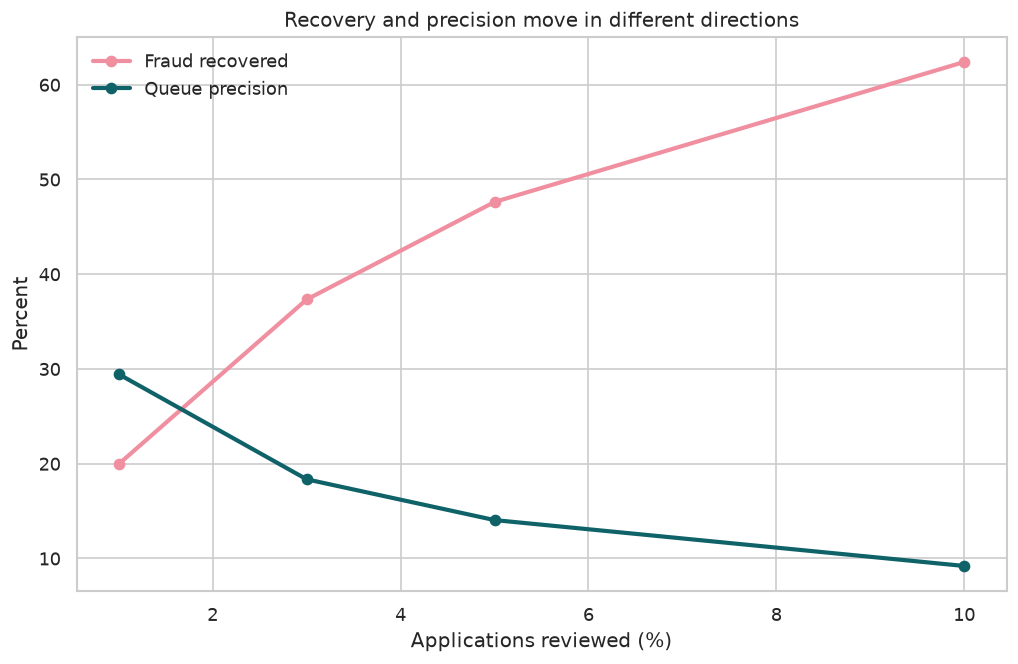

In [6]:
fig, axis = plt.subplots(figsize=(10, 6))
axis.plot(capacity.review_share * 100, capacity.recall_at_capacity * 100, color=CORAL, marker="o", linewidth=2.5, label="Fraud recovered")
axis.plot(capacity.review_share * 100, capacity.precision_at_capacity * 100, color=TEAL, marker="o", linewidth=2.5, label="Queue precision")
axis.set(xlabel="Applications reviewed (%)", ylabel="Percent", title="Recovery and precision move in different directions")
axis.legend(frameon=False)
plt.show()

Increasing capacity recovers more fraud but lowers the concentration of fraud inside the queue. A business decision therefore requires both the cost of a missed fraud and the cost of a manual review; those costs are not supplied and are not invented here.

## 3. Recommended reporting point

The portfolio uses three percent as a transparent comparison scenario, not as a production recommendation. At this capacity, 2,905 applications are reviewed, 533 fraud cases are captured and 2,372 reviews are false positives.

## Conclusion

A model metric is not an operating policy. The review-capacity analysis makes the workload and missed-fraud trade-off visible before any claim of business value.